# Booking Funnel Analysis (NYC vs Dubai)

**Business Question:** *"Where does the OTA booking funnel leak for Dubai vs NYC — and what market-level factors cause it?"*

| # | Source | Signal | Used For |
|---|--------|--------|----------|
| 1 | Processed hotels dataset | ratings, reviews, price levels, visibility | Funnel diagnostics |
| 2 | Processed funnel features | price/rating tiers, bookability flags | Stage-level conversion simulation |

### Why This Matters
NYC travelers booking Dubai hotels often face:
- Unfamiliarity with hotel brands
- Perceived higher prices
- Trust mismatch (review context)
- Choice complexity

### Pipeline
1. Load **processed** hotel funnel dataset
2. Validate schema
3. Compare markets side-by-side
4. Simulate 5-stage funnel per market
5. Diagnose stage-level leak and recommend actions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config.settings import DATA_PROCESSED, FIGURES_DIR
from src.analysis.funnel_analyzer import compare_markets, simulate_booking_funnel

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "booking_funnel").mkdir(parents=True, exist_ok=True)

COLORS = {"Dubai": "#E53935", "NYC": "#1E88E5"}
print("Setup complete ✅")

Setup complete ✅


In [3]:
# Robust processed-only loader for booking funnel
from pathlib import Path

cand = [
    DATA_PROCESSED / "hotels_prepared.parquet",
    DATA_PROCESSED / "hotels_prepared.csv",
    DATA_PROCESSED / "hotels.parquet",
    DATA_PROCESSED / "hotels.csv",
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched.csv",
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched_processed.csv",
]

found = [p for p in cand if p.exists()]
print("Found candidate files:")
for p in found:
    print(" -", p)

hotels = None
source_used = None
errors = []

for p in found:
    try:
        if p.suffix == ".parquet":
            hotels = pd.read_parquet(p)
        else:
            hotels = pd.read_csv(p)
        source_used = str(p)
        break
    except Exception as e:
        errors.append(f"{p.name}: {e}")

if hotels is None:
    raise FileNotFoundError(
        "No readable processed hotel file found.\n"
        f"Checked:\n" + "\n".join(str(x) for x in cand) + "\n\n"
        f"Read errors: {errors}\n\n"
        "Run: python scripts/preprocess_all.py --source seeds"
    )

# normalize numeric columns
for col in ["RATING", "TOTAL_RATINGS", "PRICE_LEVEL", "VISIBILITY_SCORE"]:
    if col in hotels.columns:
        hotels[col] = pd.to_numeric(hotels[col], errors="coerce")

if "MARKET" not in hotels.columns:
    raise ValueError(f"Loaded file missing MARKET column: {source_used}")

print(f"\n✅ Loaded processed source: {source_used}")
print(f"Rows: {len(hotels)}")
print("Markets:", hotels["MARKET"].value_counts(dropna=False).to_dict())
display(hotels.head())

Found candidate files:
 - C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\hotels_prepared.parquet
 - C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_enriched.csv

✅ Loaded processed source: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_enriched.csv
Rows: 202
Markets: {'NYC': 106, 'Dubai': 96}


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,92.8,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,84.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,52.4,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,52.8,True


In [4]:
required = [
    "MARKET", "RATING", "TOTAL_RATINGS", "PRICE_LEVEL",
    "PRICE_TIER", "RATING_TIER", "VISIBILITY_SCORE", "IS_BOOKABLE"
]
missing = [c for c in required if c not in hotels.columns]
if missing:
    raise ValueError(f"Missing required processed columns: {missing}")

print("Processed features available ✅")
print(f"PRICE_TIER counts: {hotels['PRICE_TIER'].value_counts().to_dict()}")
print(f"RATING_TIER counts: {hotels['RATING_TIER'].value_counts().to_dict()}")
print(f"Bookable share: {hotels['IS_BOOKABLE'].mean():.1%}")

Processed features available ✅
PRICE_TIER counts: {'Unknown': 196, 'Upscale': 4, 'Luxury': 2}
RATING_TIER counts: {'Excellent': 78, 'Good': 68, 'Average': 37, 'Low': 19}
Bookable share: 99.0%



## Market Comparison — Dubai vs NYC

In [5]:

comparison = compare_markets(hotels)
display(comparison)

,MARKET,TOTAL_LISTINGS,BOOKABLE_LISTINGS,BOOKABILITY_RATE,AVG_PRICE_LEVEL,AVG_RATING,AVG_VISIBILITY
0,Dubai,96,94,97.9,NaN,4.43,55.3
1,NYC,106,106,100.0,3.33,3.97,53.1


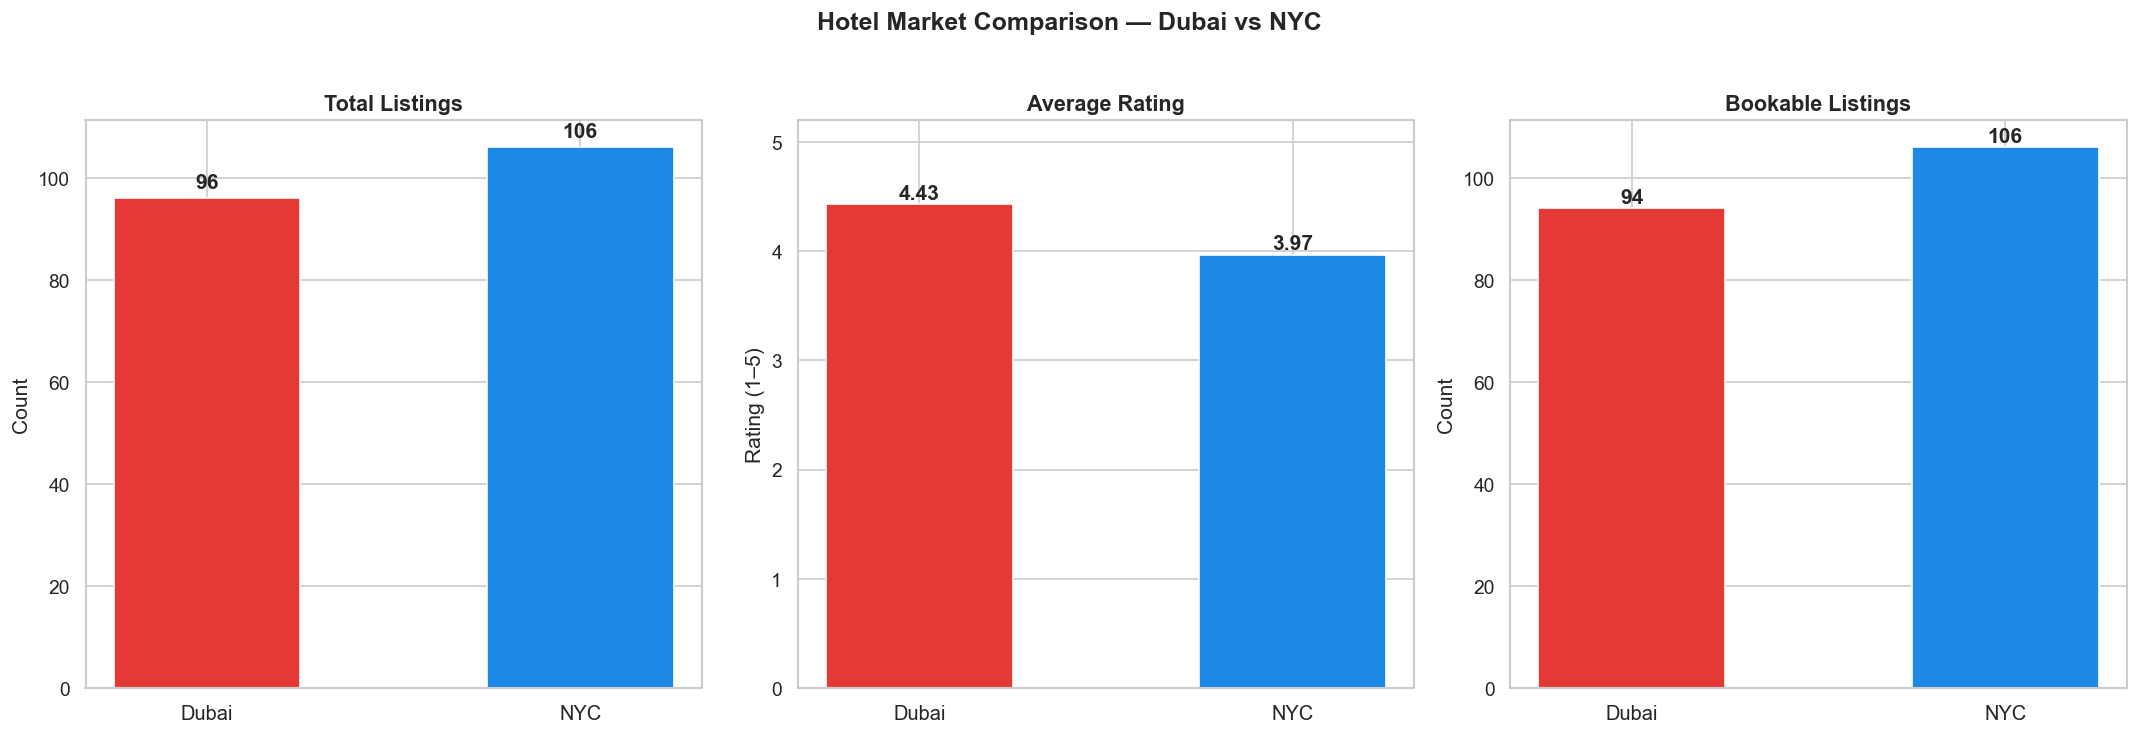

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markets = comparison["MARKET"].tolist()
x = np.arange(len(markets))

# Total Listings
bars = axes[0].bar(x, comparison["TOTAL_LISTINGS"], width=0.5,
                   color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
axes[0].set_title("Total Listings", fontsize=13, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(markets, fontsize=12)
axes[0].set_ylabel("Count")
for b, v in zip(bars, comparison["TOTAL_LISTINGS"]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+2, f"{int(v)}", ha="center", fontweight="bold")

# Avg Rating
bars = axes[1].bar(x, comparison["AVG_RATING"], width=0.5,
                   color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
axes[1].set_title("Average Rating", fontsize=13, fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(markets, fontsize=12)
axes[1].set_ylabel("Rating (1–5)"); axes[1].set_ylim(0, 5.2)
for b, v in zip(bars, comparison["AVG_RATING"]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{v:.2f}", ha="center", fontweight="bold")

# Avg Reviews
review_col = "AVG_TOTAL_RATINGS" if "AVG_TOTAL_RATINGS" in comparison.columns else "BOOKABLE_LISTINGS"
bars = axes[2].bar(x, comparison[review_col], width=0.5,
                   color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
axes[2].set_title("Avg Reviews per Hotel" if review_col=="AVG_TOTAL_RATINGS" else "Bookable Listings",
                  fontsize=13, fontweight="bold")
axes[2].set_xticks(x); axes[2].set_xticklabels(markets, fontsize=12)
axes[2].set_ylabel("Count")
for b, v in zip(bars, comparison[review_col]):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{v:,.0f}", ha="center", fontweight="bold")

plt.suptitle("Hotel Market Comparison — Dubai vs NYC", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_market_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Price Tier Analysis

In [7]:
price_dist = (
    hotels.groupby(["MARKET", "PRICE_TIER"], dropna=False)
    .agg(
        COUNT=("PRICE_TIER", "size"),
        AVG_RATING=("RATING", "mean")
    )
    .reset_index()
)

market_totals = price_dist.groupby("MARKET")["COUNT"].transform("sum")
price_dist["PCT_OF_MARKET"] = (price_dist["COUNT"] / market_totals * 100).round(1)

display(price_dist.sort_values(["MARKET", "PRICE_TIER"]))

,MARKET,PRICE_TIER,COUNT,AVG_RATING,PCT_OF_MARKET
0,Dubai,Unknown,96,4.433333,100.0
1,NYC,Luxury,2,4.000000,1.9
2,NYC,Unknown,100,3.955000,94.3
3,NYC,Upscale,4,4.225000,3.8


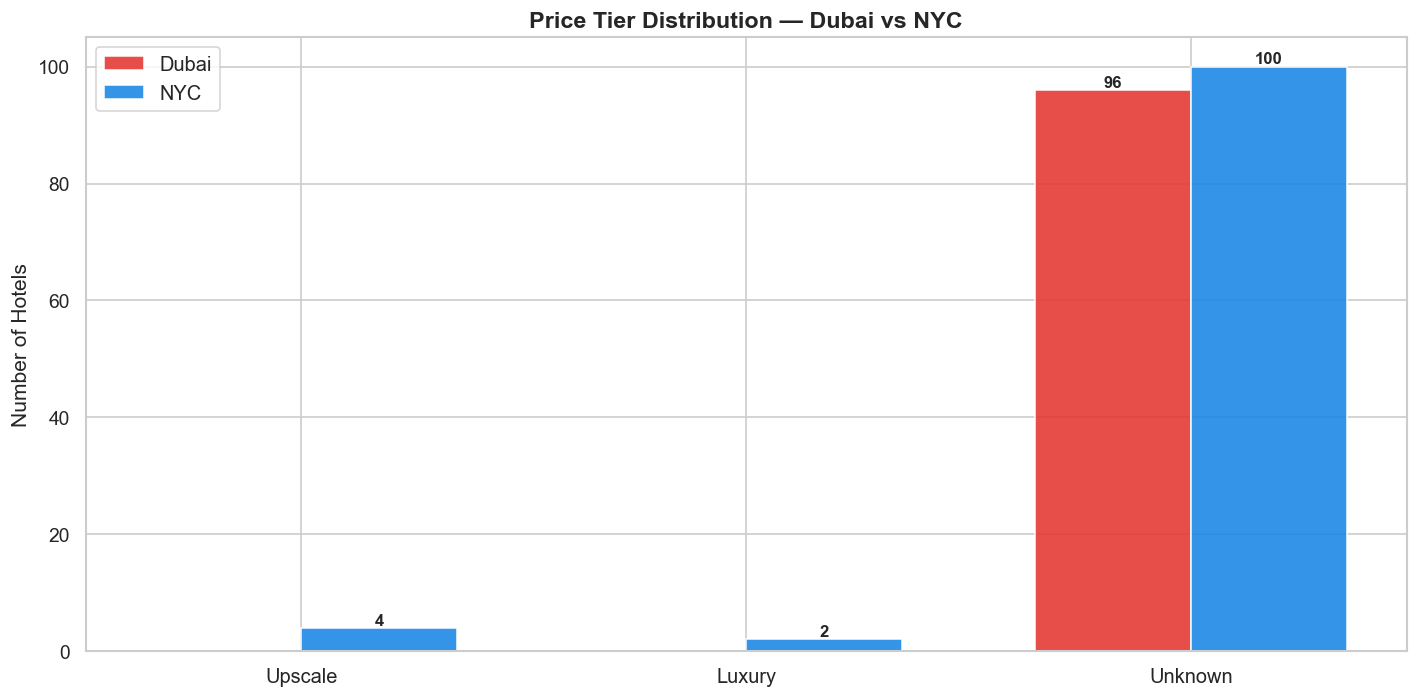

In [8]:
tier_order = ["Budget", "Mid-Range", "Upscale", "Luxury", "Unknown"]
available_tiers = [t for t in tier_order if t in price_dist["PRICE_TIER"].values]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(available_tiers))

for i, market in enumerate(["Dubai", "NYC"]):
    mdata = price_dist[price_dist["MARKET"] == market]
    counts = [mdata.loc[mdata["PRICE_TIER"] == t, "COUNT"].values[0] if t in mdata["PRICE_TIER"].values else 0
              for t in available_tiers]
    offset = -bar_width/2 + i * bar_width
    bars = ax.bar(x + offset, counts, bar_width, label=market, color=COLORS[market], edgecolor="white", alpha=0.9)
    for b, v in zip(bars, counts):
        if v > 0:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{int(v)}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(available_tiers, fontsize=12)
ax.set_ylabel("Number of Hotels")
ax.set_title("Price Tier Distribution — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_price_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

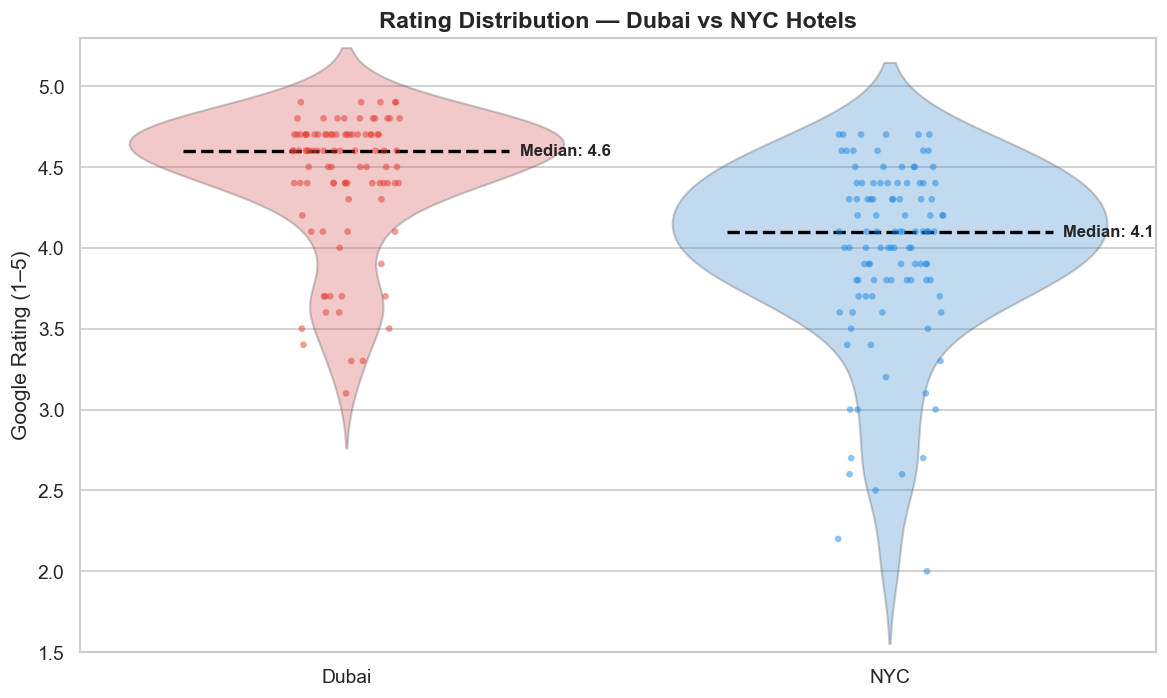

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=hotels, x="MARKET", y="RATING", palette=COLORS, inner=None, alpha=0.3, ax=ax)
sns.stripplot(data=hotels, x="MARKET", y="RATING", palette=COLORS, size=4, alpha=0.5, jitter=True, ax=ax)

for i, market in enumerate(["Dubai", "NYC"]):
    m = hotels[hotels["MARKET"] == market]["RATING"].median()
    ax.hlines(m, i - 0.3, i + 0.3, colors="black", linewidth=2, linestyle="--")
    ax.text(i + 0.32, m, f"Median: {m:.1f}", fontsize=10, fontweight="bold", va="center")

ax.set_title("Rating Distribution — Dubai vs NYC Hotels", fontsize=14, fontweight="bold")
ax.set_ylabel("Google Rating (1–5)")
ax.set_xlabel("")
ax.set_ylim(1.5, 5.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Trust Quadrant — Rating vs Review Volume

In [10]:
hotels_trust = hotels.copy()
rating_med = hotels_trust.groupby("MARKET")["RATING"].transform("median")
reviews_med = hotels_trust.groupby("MARKET")["TOTAL_RATINGS"].transform("median")

cond_star = (hotels_trust["RATING"] >= rating_med) & (hotels_trust["TOTAL_RATINGS"] >= reviews_med)
cond_hidden = (hotels_trust["RATING"] >= rating_med) & (hotels_trust["TOTAL_RATINGS"] < reviews_med)
cond_risky = (hotels_trust["RATING"] < rating_med) & (hotels_trust["TOTAL_RATINGS"] >= reviews_med)

hotels_trust["TRUST_QUADRANT"] = np.select(
    [cond_star, cond_hidden, cond_risky],
    ["⭐ Star Performer", "🔍 Hidden Gem", "⚠️ Known but Risky"],
    default="❌ Low Signal"
)

quad_summary = (
    hotels_trust.groupby(["MARKET", "TRUST_QUADRANT"])
    .size()
    .reset_index(name="COUNT")
    .sort_values(["MARKET", "COUNT"], ascending=[True, False])
)

display(quad_summary)

,MARKET,TRUST_QUADRANT,COUNT
2,Dubai,⭐ Star Performer,39
1,Dubai,❌ Low Signal,34
3,Dubai,🔍 Hidden Gem,14
0,Dubai,⚠️ Known but Risky,9
7,NYC,🔍 Hidden Gem,28
6,NYC,⭐ Star Performer,27
4,NYC,⚠️ Known but Risky,26
5,NYC,❌ Low Signal,25


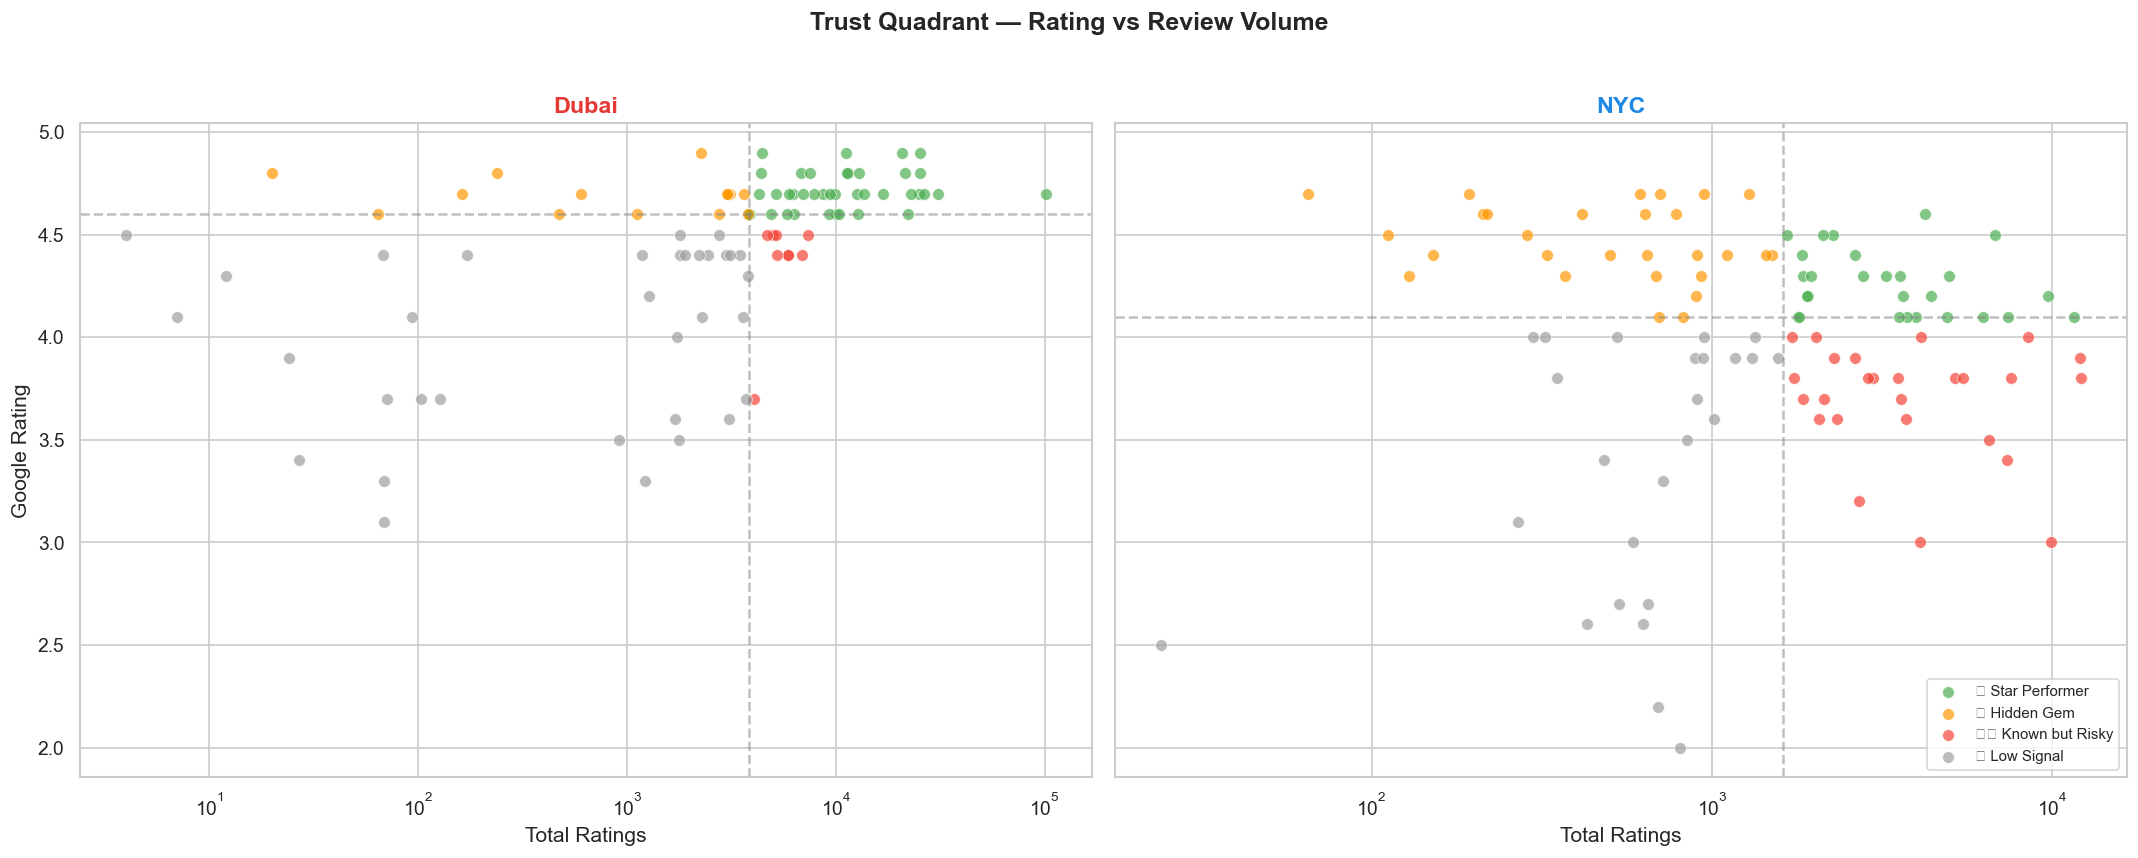

In [11]:
quadrant_colors = {
    "⭐ Star Performer": "#4CAF50",
    "🔍 Hidden Gem": "#FF9800",
    "⚠️ Known but Risky": "#F44336",
    "❌ Low Signal": "#9E9E9E",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, market in enumerate(["Dubai", "NYC"]):
    ax = axes[idx]
    mdf = hotels_trust[hotels_trust["MARKET"] == market]

    for quad, color in quadrant_colors.items():
        qdf = mdf[mdf["TRUST_QUADRANT"] == quad]
        if len(qdf):
            ax.scatter(qdf["TOTAL_RATINGS"], qdf["RATING"], c=color, label=quad,
                       s=50, alpha=0.7, edgecolors="white", linewidth=0.5)

    ax.axhline(mdf["RATING"].median(), color="gray", ls="--", alpha=0.5)
    ax.axvline(mdf["TOTAL_RATINGS"].median(), color="gray", ls="--", alpha=0.5)
    ax.set_title(market, fontsize=14, fontweight="bold", color=COLORS[market])
    ax.set_xlabel("Total Ratings")
    if idx == 0:
        ax.set_ylabel("Google Rating")
    ax.set_xscale("log")
    if idx == 1:
        ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Trust Quadrant — Rating vs Review Volume", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_trust_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()


## Booking Funnel Simulation

5-stage funnel: **Search → View → Compare → Intent → Book**

In [12]:
dubai_funnel = simulate_booking_funnel(hotels, "Dubai")
nyc_funnel = simulate_booking_funnel(hotels, "NYC")

def get_funnel_summary_local(df, market):
    stages = ["STAGE_1_SEARCH", "STAGE_2_VIEW", "STAGE_3_COMPARE", "STAGE_4_INTENT", "STAGE_5_BOOK"]
    labels = ["Search", "View", "Compare", "Intent", "Book"]
    visitors = [df[s].sum() for s in stages]
    drop = [np.nan]
    for i in range(1, len(visitors)):
        prev = visitors[i-1] if visitors[i-1] else np.nan
        drop.append((1 - visitors[i]/prev) * 100 if prev and not np.isnan(prev) else np.nan)

    out = pd.DataFrame({
        "MARKET": market,
        "STAGE": labels,
        "VISITORS": visitors,
        "DROP_OFF_PCT": drop
    })
    out["OVERALL_CONVERSION_PCT"] = out["VISITORS"] / out.loc[0, "VISITORS"] * 100
    return out

dubai_summary = get_funnel_summary_local(dubai_funnel, "Dubai")
nyc_summary = get_funnel_summary_local(nyc_funnel, "NYC")

print("Dubai Funnel:")
display(dubai_summary)
print("\nNYC Funnel:")
display(nyc_summary)

print(f"\nOverall Search→Book conversion:")
print(f"  Dubai: {dubai_summary.iloc[-1]['OVERALL_CONVERSION_PCT']:.2f}%")
print(f"  NYC:   {nyc_summary.iloc[-1]['OVERALL_CONVERSION_PCT']:.2f}%")

Dubai Funnel:


,MARKET,STAGE,VISITORS,DROP_OFF_PCT,OVERALL_CONVERSION_PCT
0,Dubai,Search,9993,NaN,100.000000
1,Dubai,View,6327,36.685680,63.314320
2,Dubai,Compare,2472,60.929350,24.737316
3,Dubai,Intent,789,68.082524,7.895527
4,Dubai,Book,547,30.671736,5.473832



NYC Funnel:


,MARKET,STAGE,VISITORS,DROP_OFF_PCT,OVERALL_CONVERSION_PCT
0,NYC,Search,10002,NaN,100.000000
1,NYC,View,4405,55.958808,44.041192
2,NYC,Compare,2163,50.896708,21.625675
3,NYC,Intent,717,66.851595,7.168566
4,NYC,Book,353,50.767085,3.529294



Overall Search→Book conversion:
  Dubai: 5.47%
  NYC:   3.53%


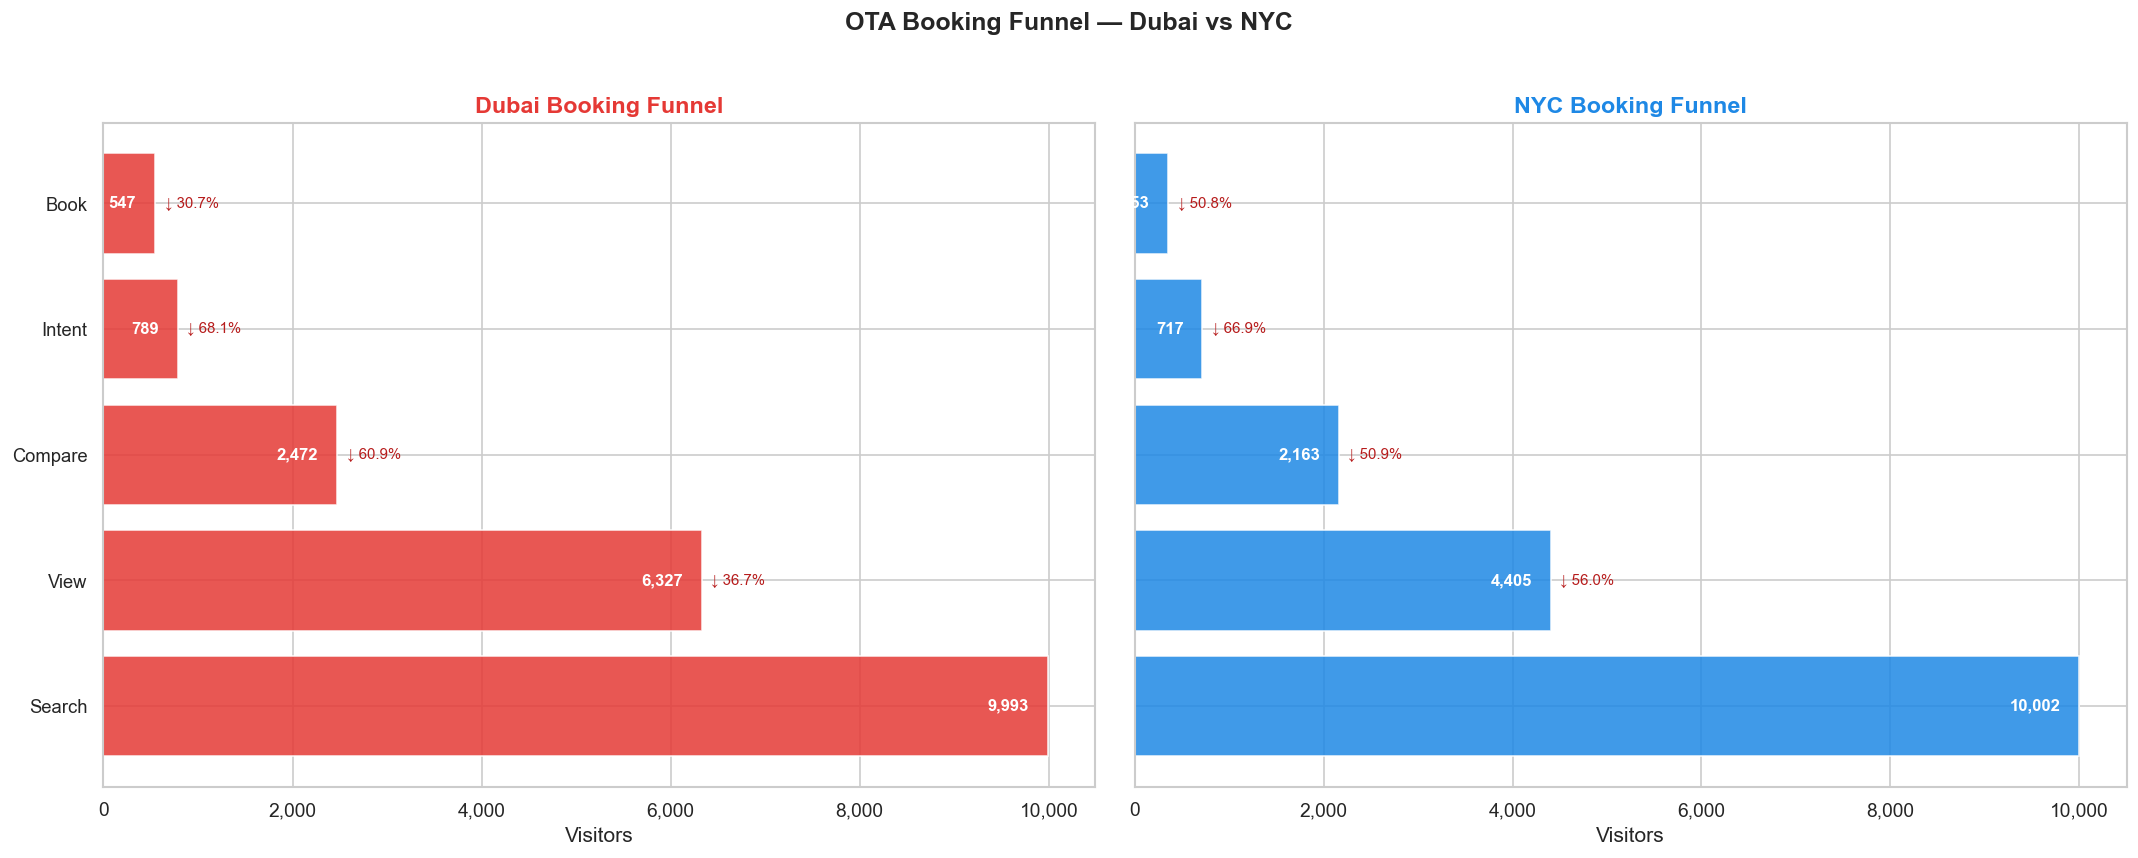

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, (summary, market) in enumerate([(dubai_summary, "Dubai"), (nyc_summary, "NYC")]):
    ax = axes[idx]
    stages = summary["STAGE"].tolist()
    visitors = summary["VISITORS"].tolist()
    dropoffs = summary["DROP_OFF_PCT"].tolist()

    y_pos = np.arange(len(stages))
    bars = ax.barh(y_pos, visitors, color=COLORS[market], alpha=0.85, edgecolor="white")

    max_v = max(visitors)
    for bar, v, d in zip(bars, visitors, dropoffs):
        ax.text(bar.get_width() - max_v * 0.02, bar.get_y() + bar.get_height()/2,
                f"{v:,.0f}", ha="right", va="center", fontsize=10, fontweight="bold", color="white")
        if not np.isnan(d) and d > 0:
            ax.text(bar.get_width() + max_v * 0.01, bar.get_y() + bar.get_height()/2,
                    f"↓ {d:.1f}%", ha="left", va="center", fontsize=9, color="#B71C1C")

    ax.set_yticks(y_pos); ax.set_yticklabels(stages, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel("Visitors")
    ax.set_title(f"{market} Booking Funnel", fontsize=14, fontweight="bold", color=COLORS[market])
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("OTA Booking Funnel — Dubai vs NYC", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_funnel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

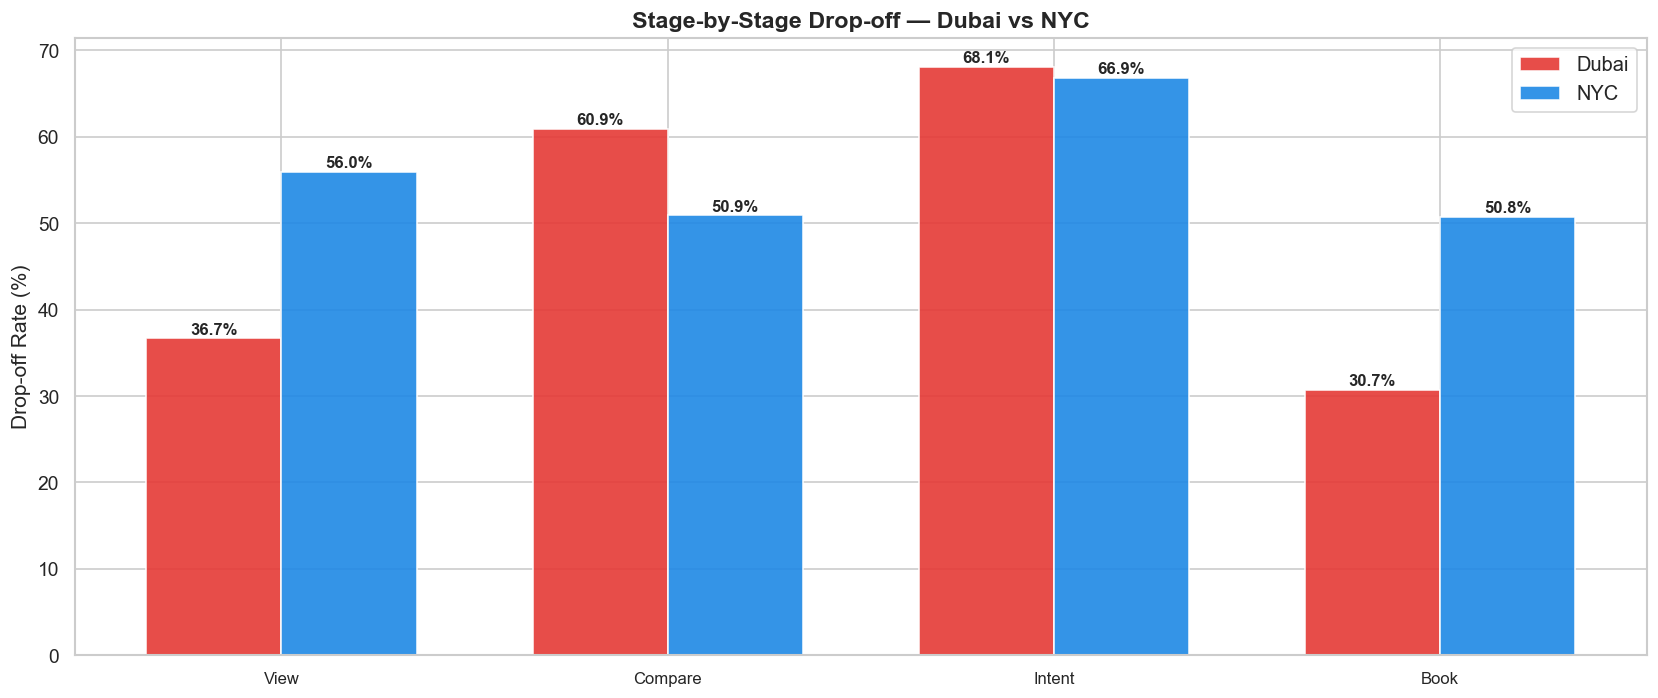

In [14]:
merged_funnel = pd.concat([dubai_summary, nyc_summary], ignore_index=True)
dropoff_data = merged_funnel[merged_funnel["DROP_OFF_PCT"] > 0].copy()

stages = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["STAGE"].tolist()
x = np.arange(len(stages))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
dubai_drops = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["DROP_OFF_PCT"].tolist()
nyc_drops = dropoff_data[dropoff_data["MARKET"] == "NYC"]["DROP_OFF_PCT"].tolist()

bars1 = ax.bar(x - bar_width/2, dubai_drops, bar_width, label="Dubai", color=COLORS["Dubai"], edgecolor="white", alpha=0.9)
bars2 = ax.bar(x + bar_width/2, nyc_drops, bar_width, label="NYC", color=COLORS["NYC"], edgecolor="white", alpha=0.9)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(stages, fontsize=10)
ax.set_ylabel("Drop-off Rate (%)")
ax.set_title("Stage-by-Stage Drop-off — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_dropoff_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Drop-off Diagnosis — Actionable Insights

In [15]:
d = dubai_summary[["STAGE", "DROP_OFF_PCT"]].rename(columns={"DROP_OFF_PCT": "DROP_OFF_PCT_DUBAI"})
n = nyc_summary[["STAGE", "DROP_OFF_PCT"]].rename(columns={"DROP_OFF_PCT": "DROP_OFF_PCT_NYC"})

diagnosis = d.merge(n, on="STAGE", how="inner")
diagnosis["DROPOFF_GAP"] = diagnosis["DROP_OFF_PCT_DUBAI"] - diagnosis["DROP_OFF_PCT_NYC"]
diagnosis["WORSE_MARKET"] = np.where(diagnosis["DROPOFF_GAP"] > 0, "Dubai", "NYC")

def _diag(row):
    s = row["STAGE"]
    if s == "View":
        return "Visibility / listing attractiveness issue"
    if s == "Compare":
        return "Price-value mismatch or inadequate anchoring"
    if s == "Intent":
        return "Offer confidence problem (trust, cancellation, deal clarity)"
    if s == "Book":
        return "Checkout friction or final trust barrier"
    return "Top-of-funnel mismatch"

diagnosis["DIAGNOSIS"] = diagnosis.apply(_diag, axis=1)

display_cols = ["STAGE", "DROP_OFF_PCT_DUBAI", "DROP_OFF_PCT_NYC", "DROPOFF_GAP", "WORSE_MARKET", "DIAGNOSIS"]
styled = (
    diagnosis[display_cols]
    .style
    .format({
        "DROP_OFF_PCT_DUBAI": "{:.1f}%",
        "DROP_OFF_PCT_NYC": "{:.1f}%",
        "DROPOFF_GAP": "{:+.1f}pp",
    })
    .background_gradient(subset=["DROPOFF_GAP"], cmap="RdYlGn_r", vmin=-20, vmax=20)
)
styled

,STAGE,DROP_OFF_PCT_DUBAI,DROP_OFF_PCT_NYC,DROPOFF_GAP,WORSE_MARKET,DIAGNOSIS
0,Search,nan%,nan%,+nanpp,NYC,Top-of-funnel mismatch
1,View,36.7%,56.0%,-19.3pp,NYC,Visibility / listing attractiveness issue
2,Compare,60.9%,50.9%,+10.0pp,Dubai,Price-value mismatch or inadequate anchoring
3,Intent,68.1%,66.9%,+1.2pp,Dubai,"Offer confidence problem (trust, cancellation, deal clarity)"
4,Book,30.7%,50.8%,-20.1pp,NYC,Checkout friction or final trust barrier


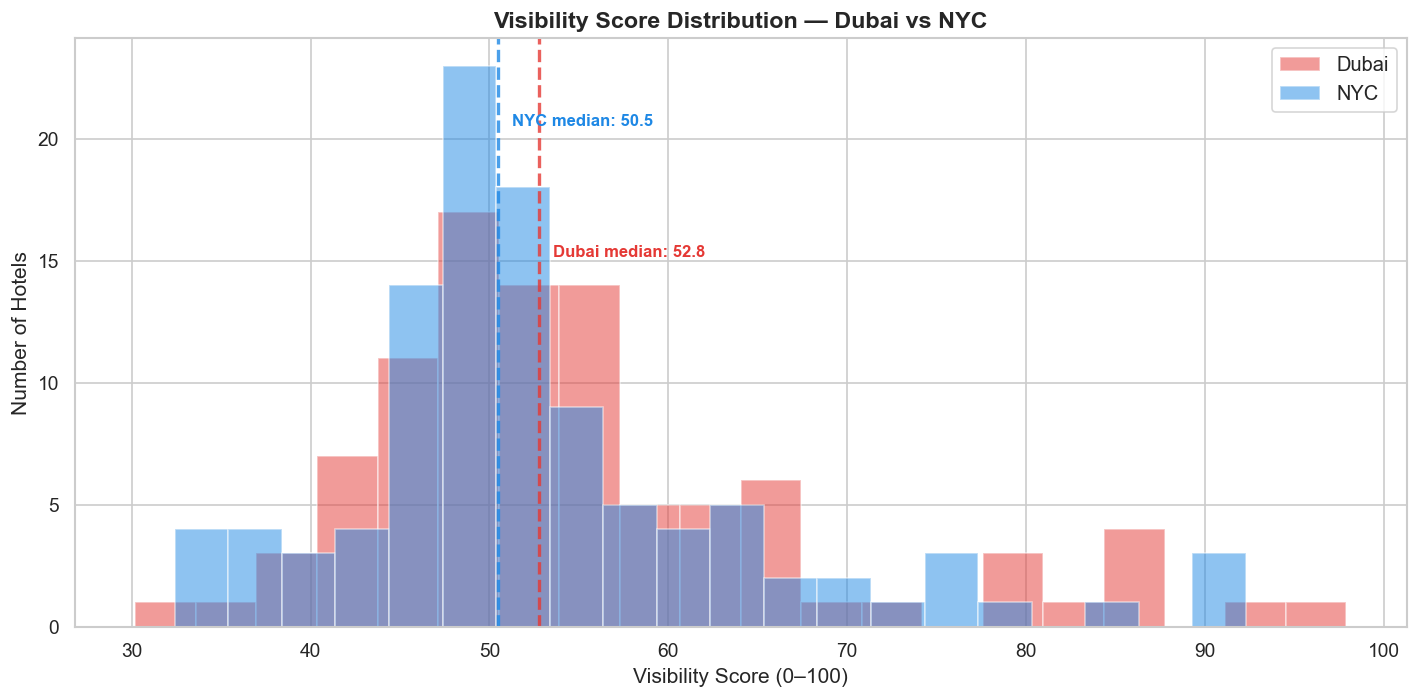

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

for market in ["Dubai", "NYC"]:
    mdf = hotels[hotels["MARKET"] == market]
    ax.hist(mdf["VISIBILITY_SCORE"], bins=20, alpha=0.5, label=market,
            color=COLORS[market], edgecolor="white")
    med = mdf["VISIBILITY_SCORE"].median()
    ax.axvline(med, color=COLORS[market], ls="--", linewidth=2, alpha=0.8)
    ax.text(med + 0.8, ax.get_ylim()[1] * 0.85, f"{market} median: {med:.1f}",
            fontsize=10, color=COLORS[market], fontweight="bold")

ax.set_xlabel("Visibility Score (0–100)")
ax.set_ylabel("Number of Hotels")
ax.set_title("Visibility Score Distribution — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_visibility_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
output_dir = DATA_PROCESSED / "booking_funnel"
output_dir.mkdir(parents=True, exist_ok=True)

hotels.to_csv(output_dir / "hotels_enriched_processed.csv", index=False)
comparison.to_csv(output_dir / "market_comparison.csv", index=False)
pd.concat([dubai_summary, nyc_summary], ignore_index=True).to_csv(output_dir / "funnel_summary.csv", index=False)
diagnosis.to_csv(output_dir / "dropoff_diagnosis.csv", index=False)
price_dist.to_csv(output_dir / "price_distribution.csv", index=False)
hotels_trust.to_csv(output_dir / "hotels_trust_quadrant.csv", index=False)

print(f"Outputs saved to: {output_dir}")
print(f"Figures saved to: {FIGURES_DIR}")

Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel
Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures


## Executive Summary — M02 Booking Funnel

### Key Findings

| # | Finding | Dubai | NYC | OTA Action |
|---|---------|-------|-----|-----------|
| 1 | **Supply density** | 96 listings | 106 listings | Curate Dubai shortlist to reduce choice overload |
| 2 | **Price skew** | Unknown 100.0% | Unknown 94.3%, Upscale 3.8% | Add bundles / price anchoring |
| 3 | **Rating quality** | Avg 4.43 | Avg 3.97 | Highlight Dubai quality proof |
| 4 | **Review volume gap** | Avg 7,192 reviews/hotel | Avg 2,484 reviews/hotel | Add trust badges, verified traveler reviews |
| 5 | **Worst funnel stage** | Intent (68.1% drop) | Intent (66.9% drop) | Optimize intent-stage UX and reassurance elements |
| 6 | **Overall conversion** | 5.47% Search→Book | 3.53% Search→Book | Scale what works in Dubai and close NYC intent friction |

### Recommended Actions
1. Fix the **Intent stage** first (highest leakage in both markets): clearer cancellation policy, final-price transparency, trust badges near CTA.
2. Improve pricing clarity with **bundle anchors** and “best value” tags.
3. Standardize missing price-tier metadata (currently “Unknown” dominates), as this limits pricing strategy precision.
4. Promote high-rating inventory with social proof modules (review snippets, verified-booker badges).